In [1]:
%matplotlib inline

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import least_squares
from scipy.linalg import expm, solve_continuous_lyapunov

plt.rcParams.update({
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

CWD = Path.cwd().resolve()
if (CWD / "data" / "seasonality" / "french_panel.csv").exists():
    CODE = CWD
elif (CWD.parent / "data" / "seasonality" / "french_panel.csv").exists():
    CODE = CWD.parent
else:
    raise FileNotFoundError("Run this notebook from the repo root or from notebooks/.")

DATA = CODE / "data"
OUT = DATA / "kalman"
FIG = CODE / "notebooks" / "figures"
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

pr = pd.read_csv(DATA / "seasonality" / "french_panel.csv", index_col=0)["log_price_resid"].to_numpy(float)
pr = pr[np.isfinite(pr)]
pr = pr - pr.mean()
N = len(pr)
v0 = float(pr @ pr / N)

def acf(k):
    k = int(k)
    return 1.0 if k == 0 else float(pr[:-k] @ pr[k:] / ((N - k) * v0))

short_lags = np.arange(1, 337)
long_anchor_lags = np.array([384, 432, 504, 600, 720, 960, 1200, 1440, 1800, 2160, 2520, 2880])
lags = np.concatenate([short_lags, long_anchor_lags])
rho_emp = np.array([acf(k) for k in lags])
nlag = len(lags)

wts = 1 / np.sqrt(lags.astype(float))
wts[lags <= 72] *= 2
wts[lags >= 168] *= 2
for anchor in [1, 6, 12, 18, 24, 30, 48, 72, 96, 120, 144, 168, 336, 720, 1440, 2160, 2520, 2880]:
    wts[lags == anchor] *= 8
sw = np.sqrt(wts / wts.mean())

def softmax(z):
    z = np.asarray(z, dtype=float)
    z = z - z.max()
    e = np.exp(z)
    return e / e.sum()

print(f"{N:,} hourly deseasonalised log-price residuals")
print(f"variance target v0 = {v0:.6e}")
print(f"ACF target lags: {nlag} lags, 1h to {lags.max()}h")
print(f"  short dense lags: {short_lags[0]}..{short_lags[-1]}h")
print(f"  long anchor lags: {long_anchor_lags.tolist()}h")

17,521 hourly deseasonalised log-price residuals
variance target v0 = 7.996979e-04
ACF target lags: 347 lags, 1h to 2520h


kind,half_life_h,half_life_d,period_h,share
osc,101.40,4.23,24.0,0.038
real,1.24,0.05,inf,0.138
real,34.26,1.43,inf,0.702
real,1680.00,70.00,inf,0.122


RMSE=0.032191  WSSR=0.2104  (CARMA order 5)


lag_h,empirical,model,err
1,0.9328,0.9251,-0.0077
2,0.8665,0.8735,+0.0070
3,0.8151,0.8344,+0.0193
6,0.7240,0.7481,+0.0241
12,0.6620,0.6371,-0.0249
18,0.5985,0.6087,+0.0102
24,0.6241,0.5849,-0.0391
30,0.4860,0.5031,+0.0170
48,0.4264,0.4128,-0.0136
72,0.3243,0.3053,-0.0190


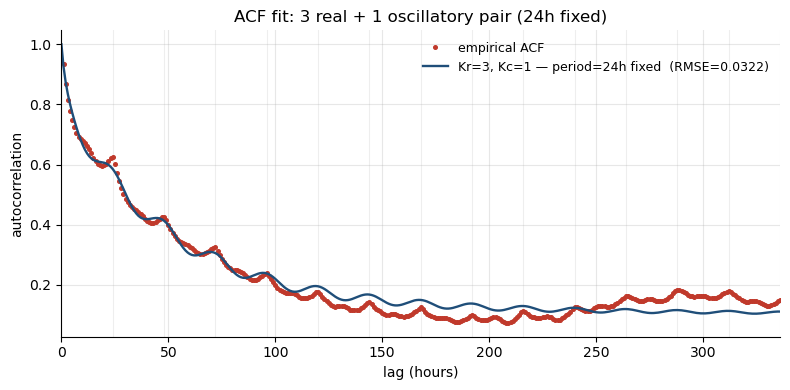

In [2]:
# ── Kr=3, Kc=1 with fixed 24h period ─────────────────────────────
# Adds one real eigenvalue relative to the previous Kr=2,Kc=1 run.
Kr, Kc = 3, 1
m = Kr + Kc
om_c_fixed = np.array([2 * np.pi / 24.0])

def rho_24(theta, k):
    # ACF model with Kr real modes and one fixed daily oscillatory pair.
    kap = np.log(2) / np.exp(theta[:m])
    sh = softmax(theta[m:2 * m])
    h = np.asarray(k, dtype=float)

    out = np.zeros_like(h, dtype=float)
    for i in range(Kr):
        out += sh[i] * np.exp(-kap[i] * h)
    for j in range(Kc):
        idx = Kr + j
        out += sh[idx] * np.exp(-kap[idx] * h) * np.cos(om_c_fixed[j] * h)
    return out

# All half-lives are bounded above so the slowest eigenvalue is <= 70 days.
# The oscillatory half-life remains constrained to >= 2 days.
max_half_life_h = 70.0 * 24.0
lb_hl = [np.log(0.3)] * Kr + [np.log(48.0)] * Kc
ub_hl = [np.log(max_half_life_h)] * m
lb = lb_hl + [-9.0] * m
ub = ub_hl + [9.0] * m

start_hl = [
    [8.0, 36.0, 1500.0, 96.0],
    [10.0, 36.0, 1200.0, 96.0],
    [6.0, 30.0, 1600.0, 96.0],
    [12.0, 48.0, 1000.0, 96.0],
    [4.0, 24.0, 800.0, 96.0],
]

rng = np.random.default_rng(42)
best = None
n_starts = 64
for s in range(n_starts):
    if s < len(start_hl):
        xs = np.r_[np.log(start_hl[s]), [0.0] * m]
    else:
        xs = np.r_[np.log(start_hl[s % len(start_hl)]), [0.0] * m]
        xs[:m] += rng.normal(0, 0.55, m)
        xs[m:2 * m] += rng.normal(0, 1.1, m)
    xs = np.clip(xs, lb, ub)
    r = least_squares(
        lambda t: sw * (rho_24(t, lags) - rho_emp),
        xs,
        bounds=(lb, ub),
        max_nfev=7000,
    )
    if best is None or r.cost < best.cost:
        best = r

kap_b = np.log(2) / np.exp(best.x[:m])
sh_b = softmax(best.x[m:2 * m])

rows = []
for i in range(Kr):
    hl_h = np.log(2) / kap_b[i]
    rows.append({
        "kind": "real",
        "half_life_h": hl_h,
        "half_life_d": hl_h / 24.0,
        "period_h": np.inf,
        "share": sh_b[i],
    })
for j in range(Kc):
    idx = Kr + j
    hl_h = np.log(2) / kap_b[idx]
    rows.append({
        "kind": "osc",
        "half_life_h": hl_h,
        "half_life_d": hl_h / 24.0,
        "period_h": 24.0,
        "share": sh_b[idx],
    })

summary_24 = pd.DataFrame(rows).sort_values(["kind", "half_life_h"]).reset_index(drop=True)
display(summary_24.style.format({
    "half_life_h": "{:.2f}",
    "half_life_d": "{:.2f}",
    "period_h": "{:.1f}",
    "share": "{:.3f}",
}).hide(axis="index"))

rmse_24 = float(np.sqrt(np.mean((rho_24(best.x, lags) - rho_emp) ** 2)))
wssr_24 = float(np.sum((sw * (rho_24(best.x, lags) - rho_emp)) ** 2))
print(f"RMSE={rmse_24:.6f}  WSSR={wssr_24:.4f}  (CARMA order {Kr + 2 * Kc})")

diag = [1, 2, 3, 6, 12, 18, 24, 30, 48, 72, 96, 120, 144, 168, 336, 720, 1440, 2160, 2520, 2880]
cmp = pd.DataFrame({
    "lag_h": diag,
    "empirical": [acf(k) for k in diag],
    "model": rho_24(best.x, np.array(diag, dtype=float)),
})
cmp["err"] = cmp["model"] - cmp["empirical"]
display(cmp.style.format({"empirical": "{:.4f}", "model": "{:.4f}", "err": "{:+.4f}"}).hide(axis="index"))

kk = np.unique(np.r_[np.arange(0, 337), np.arange(360, int(lags.max()) + 1, 24)])
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(lags, rho_emp, "o", ms=2.6, color="#c0392b", label="empirical ACF targets")
ax.plot(kk, rho_24(best.x, kk), "-", lw=1.7, color="#1f4e79",
        label=f"Kr=3, Kc=1 - period=24h fixed  (RMSE={rmse_24:.4f})")
for d in [336, 720, 1440, 2160, 2520, 2880]:
    if d <= lags.max():
        ax.axvline(d, color="#eee", lw=0.8, zorder=0)
ax.set_xlim(0, int(lags.max()))
ax.set_xlabel("lag (hours)")
ax.set_ylabel("autocorrelation")
ax.set_title("ACF fit: 1..14d hourly + long anchors to 120d")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

P(u) degree=4  leading=1.4682e-04  (expected 2v0·Σκw=1.4682e-04)
All b roots Re<0: True  |  max Re=-1.27e-03
b = [1.921698e-05, 1.525443e-02, 7.728508e-02, 2.605489e-01, 1.000000e+00]
b^T·P_norm·b = 5.4469e+00  (v0=7.9970e-04)

=== ACF verification ===
  Multiscale model  RMSE=0.032191  WSSR=0.2104
  Spectral b        RMSE=0.032191  WSSR=0.2104
  ΔRMSE = 1.99e-13  (should be ≈0)


lag_h,empirical,multiscale,"CARMA(5,4) sf-b",err_sf
1,0.9328,0.9251,0.9251,-0.0077
2,0.8665,0.8735,0.8735,0.0070
3,0.8151,0.8344,0.8344,0.0193
6,0.7240,0.7481,0.7481,0.0241
12,0.6620,0.6371,0.6371,-0.0249
18,0.5985,0.6087,0.6087,0.0102
24,0.6241,0.5849,0.5849,-0.0391
30,0.4860,0.5031,0.5031,0.0170
48,0.4264,0.4128,0.4128,-0.0136
72,0.3243,0.3053,0.3053,-0.0190


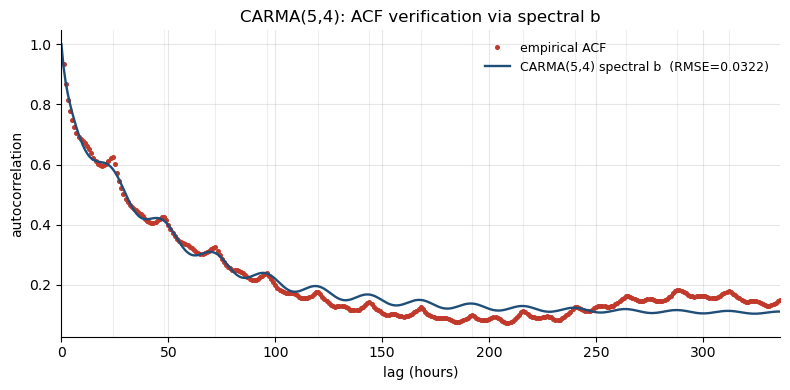

saved: price_multiscale_carma_selected.json
saved: price_carma_b_init.json
saved: price_multiscale_carma_selected_components.csv

=== Init for nb03: p=5, q=4 ===
  b = [1.921698e-05, 1.525443e-02, 7.728508e-02, 2.605489e-01, 1.000000e+00]


In [3]:
# ── Spectral factorisation CARMA(5,4) + save ─────────────────────
kap_r = kap_b[:Kr]
sh_r = sh_b[:Kr]
kap_c = kap_b[Kr:]
sh_c = sh_b[Kr:]
om_c = om_c_fixed.copy()
p = Kr + 2 * Kc

roots_ar = [complex(-kap_r[i], 0.0) for i in range(Kr)]
for j in range(Kc):
    roots_ar.extend([
        complex(-kap_c[j], om_c[j]),
        complex(-kap_c[j], -om_c[j]),
    ])
ar = np.real(np.poly(roots_ar)[1:])

A = np.zeros((p, p))
for i in range(p - 1):
    A[i, i + 1] = 1.0
A[-1, :] = -ar[::-1]
ep = np.zeros(p)
ep[-1] = 1.0
P_norm = solve_continuous_lyapunov(A, -np.outer(ep, ep))

fp_r2 = lambda k: np.array([1.0, k ** 2])
fp_c2 = lambda k, o: np.array([1.0, 2 * (k ** 2 - o ** 2), (k ** 2 + o ** 2) ** 2])
fr2 = [fp_r2(k) for k in kap_r]
fc2 = [fp_c2(k, o) for k, o in zip(kap_c, om_c)]

P_u = np.zeros(p)
for i in range(Kr):
    t = np.array([2 * kap_r[i] * sh_r[i] * v0])
    for i2 in range(Kr):
        if i2 != i:
            t = np.polymul(t, fr2[i2])
    for j in range(Kc):
        t = np.polymul(t, fc2[j])
    P_u = np.polyadd(P_u, t)

for j in range(Kc):
    t = np.polymul(
        np.array([2 * kap_c[j] * sh_c[j] * v0]),
        np.array([1.0, kap_c[j] ** 2 + om_c[j] ** 2]),
    )
    for i in range(Kr):
        t = np.polymul(t, fr2[i])
    for j2 in range(Kc):
        if j2 != j:
            t = np.polymul(t, fc2[j2])
    P_u = np.polyadd(P_u, t)

print(f"P(u) degree={len(P_u) - 1}  leading={P_u[0]:.4e}  "
      f"(expected 2v0·Σκw={2 * v0 * float(np.r_[kap_r, kap_c] @ sh_b):.4e})")

u_roots = np.roots(P_u)
b_roots = np.array([
    1j * np.sqrt(uk) if np.real(1j * np.sqrt(uk)) < np.real(-1j * np.sqrt(uk))
    else -1j * np.sqrt(uk)
    for uk in u_roots
])
print(f"All b roots Re<0: {np.all(np.real(b_roots) < 0)}  |  max Re={np.max(np.real(b_roots)):.2e}")

b_vec_raw = np.real(np.poly(b_roots)[::-1])
b_vec = b_vec_raw / b_vec_raw[-1]   # book convention: monic highest MA coefficient b_q = 1
Pb = P_norm @ b_vec
var0 = float(b_vec @ Pb)
print(f"b = {np.array2string(b_vec, precision=6, separator=', ')}")
print(f"b^T·P_norm·b = {var0:.4e}  (v0={v0:.4e})")

eAh = np.stack([expm(A * float(h)) for h in lags])
rho_sf = (eAh @ Pb) @ b_vec / var0
rmse_sf = float(np.sqrt(np.mean((rho_sf - rho_emp) ** 2)))
wssr_sf = float(np.sum((sw * (rho_sf - rho_emp)) ** 2))
print("\n=== ACF verification ===")
print(f"  Multiscale model  RMSE={rmse_24:.6f}  WSSR={wssr_24:.4f}")
print(f"  Spectral b        RMSE={rmse_sf:.6f}  WSSR={wssr_sf:.4f}")
print(f"  ΔRMSE = {rmse_sf - rmse_24:.2e}  (should be ≈0)")

diag = [1, 2, 3, 6, 12, 18, 24, 30, 48, 72, 96, 120, 144, 168, 336, 720, 1440, 2160, 2520, 2880]
eAhd = np.stack([expm(A * float(h)) for h in diag])
cmp = pd.DataFrame({
    "lag_h": diag,
    "empirical": [acf(k) for k in diag],
    "multiscale": rho_24(best.x, np.array(diag, dtype=float)),
    f"CARMA({p},{p-1}) sf-b": (eAhd @ Pb) @ b_vec / var0,
})
cmp["err_sf"] = cmp[f"CARMA({p},{p-1}) sf-b"] - cmp["empirical"]
display(cmp.style.format({c: "{:.4f}" for c in cmp.columns[1:]}).hide(axis="index"))

kk = np.unique(np.r_[np.arange(0, 337), np.arange(360, int(lags.max()) + 1, 24)])
eAhp = np.stack([expm(A * float(h)) for h in kk])
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(lags, rho_emp, "o", ms=2.6, color="#c0392b", label="empirical ACF targets")
ax.plot(kk, (eAhp @ Pb) @ b_vec / var0, "-", lw=1.7, color="#1f4e79",
        label=f"CARMA({p},{p-1}) spectral b  (RMSE={rmse_sf:.4f})")
for d in [336, 720, 1440, 2160, 2520, 2880]:
    if d <= lags.max():
        ax.axvline(d, color="#eee", lw=0.8, zorder=0)
ax.set_xlim(0, int(lags.max()))
ax.set_xlabel("lag (hours)")
ax.set_ylabel("autocorrelation")
ax.set_title(f"CARMA({p},{p-1}): spectral-b ACF, short lags + long anchors")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

def _ser(x):
    return None if (isinstance(x, float) and not np.isfinite(x)) else float(x)

components = [
    {
        "kind": str(r["kind"]),
        "half_life_h": float(r["half_life_h"]),
        "half_life_d": float(r["half_life_d"]),
        "period_h": _ser(r["period_h"]),
        "share": float(r["share"]),
    }
    for _, r in summary_24.iterrows()
]

payload = dict(
    selected=dict(Kr=Kr, Kc=Kc, order=p),
    acf_calibration=dict(
        short_lags_h=[int(x) for x in short_lags],
        long_anchor_lags_h=[int(x) for x in long_anchor_lags],
        all_lags_h=[int(x) for x in lags],
        weights=[float(x) for x in wts],
    ),
    roots=[[float(r.real), float(r.imag)] for r in roots_ar],
    ar_coefficients=[float(x) for x in ar],
    b_coefficients=[float(x) for x in b_vec],
    metrics=dict(
        rmse_multiscale=float(rmse_24),
        wssr_multiscale=float(wssr_24),
        rmse_spectral=float(rmse_sf),
        wssr_spectral=float(wssr_sf),
    ),
    components=components,
    note="Kr=3 Kc=1 period=24h fixed; calibrated on 1..14d hourly lags plus long anchors to 120d; all half-lives <= 70 days. CARMA(5,4). Monic b[-1]=1 (book convention).",
)
(OUT / "price_multiscale_carma_selected.json").write_text(json.dumps(payload, indent=2))
(OUT / "price_carma_b_init.json").write_text(json.dumps(dict(
    b_coefficients=[float(x) for x in b_vec],
    AR_order=int(p),
    MA_order=int(p - 1),
    acf_rmse_spectral=float(rmse_sf),
    acf_rmse_multiscale=float(rmse_24),
    note=f"CARMA({p},{p-1}) spectral b. Monic b[-1]=1 (book convention).",
), indent=2))

summary_24.to_csv(OUT / "price_multiscale_carma_selected_components.csv", index=False)
print("saved: price_multiscale_carma_selected.json")
print("saved: price_carma_b_init.json")
print("saved: price_multiscale_carma_selected_components.csv")
print(f"\n=== Init for nb03: p={p}, q={p - 1} ===")
print(f"  b = {np.array2string(b_vec, precision=6, separator=', ')}")